# Smartphone Sales Analytics — Exploratory Data Analysis

FY2025, India market. Source: data/smartphones.csv.

In [1]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_data
from src import analysis

df = load_data()
df.head()

,id,brand,model,price_inr,units_sold,rating,q1,q2,q3,q4,url,display,processor,camera,battery,ram,storage,revenue,segment,perf_score
0,1,Samsung,Galaxy M14 5G,11999,820000,4.2,180,210,220,210,https://www.samsung.com/in/smartphones/galaxy-...,"6.6"" FHD+ 90Hz",Exynos 1330,50MP + 2MP,6000mAh,4/6GB,64/128GB,9839180000,Budget,45
1,2,Samsung,Galaxy A05s,9999,650000,3.9,140,160,180,170,https://www.samsung.com/in/smartphones/galaxy-...,"6.7"" HD+ 60Hz",Snapdragon 680,50MP + 2MP + 2MP,5000mAh,4/6GB,64/128GB,6499350000,Budget,38
2,3,Xiaomi,Redmi 13C,8999,1150000,4.1,250,290,310,300,https://www.mi.com/in/redmi-13c/,"6.74"" HD+ 90Hz",Helio G85,50MP + 2MP,5000mAh,4/6GB,128GB,10348850000,Budget,52
3,4,Xiaomi,Redmi Note 13,13999,1420000,4.4,300,350,390,380,https://www.mi.com/in/redmi-note-13/,"6.67"" FHD+ 120Hz",Dimensity 6080,108MP + 2MP,5000mAh,6/8GB,128/256GB,19878580000,Budget,64
4,5,Realme,Realme C67,8499,780000,4.0,170,200,210,200,https://www.realme.com/in/realme-c67/,"6.72"" HD+ 90Hz",Snapdragon 685,108MP + 2MP,5000mAh,6/8GB,128/256GB,6629220000,Budget,42


## Data quality

Shape, dtypes, nulls, and summary statistics.

In [2]:
print(df.shape)
print(df.dtypes)
print("Nulls per column:\n", df.isnull().sum())
df[["price_inr", "units_sold", "rating", "revenue", "perf_score"]].describe()

(60, 20)
id              int64
brand          object
model          object
price_inr       int64
units_sold      int64
rating        float64
q1              int64
q2              int64
q3              int64
q4              int64
url            object
display        object
processor      object
camera         object
battery        object
ram            object
storage        object
revenue         int64
segment        object
perf_score      int64
dtype: object
Nulls per column:
 id            0
brand         0
model         0
price_inr     0
units_sold    0
rating        0
q1            0
q2            0
q3            0
q4            0
url           0
display       0
processor     0
camera        0
battery       0
ram           0
storage       0
revenue       0
segment       0
perf_score    0
dtype: int64


,price_inr,units_sold,rating,revenue,perf_score
count,60.000000,6.000000e+01,60.000000,6.000000e+01,60.000000
mean,48334.066667,5.201667e+05,4.331667,2.126717e+10,41.900000
std,40726.651629,2.606933e+05,0.211926,2.227234e+10,11.657107
min,6999.000000,1.200000e+05,3.800000,3.689590e+09,29.000000
25%,22249.000000,3.400000e+05,4.200000,1.001958e+10,35.000000
50%,32499.000000,4.800000e+05,4.400000,1.497940e+10,38.500000
75%,69924.750000,6.575000e+05,4.500000,2.320460e+10,44.000000
max,164999.000000,1.420000e+06,4.800000,1.151280e+11,84.000000


## KPIs

In [3]:
analysis.kpis(df)

{'total_revenue': 1276030060000,
 'total_units': 31210000,
 'avg_rating': 4.3,
 'top_brand': 'Apple',
 'top_brand_revenue': 351373000000,
 'num_brands': 12,
 'num_segments': 4}

## Revenue by brand and segment

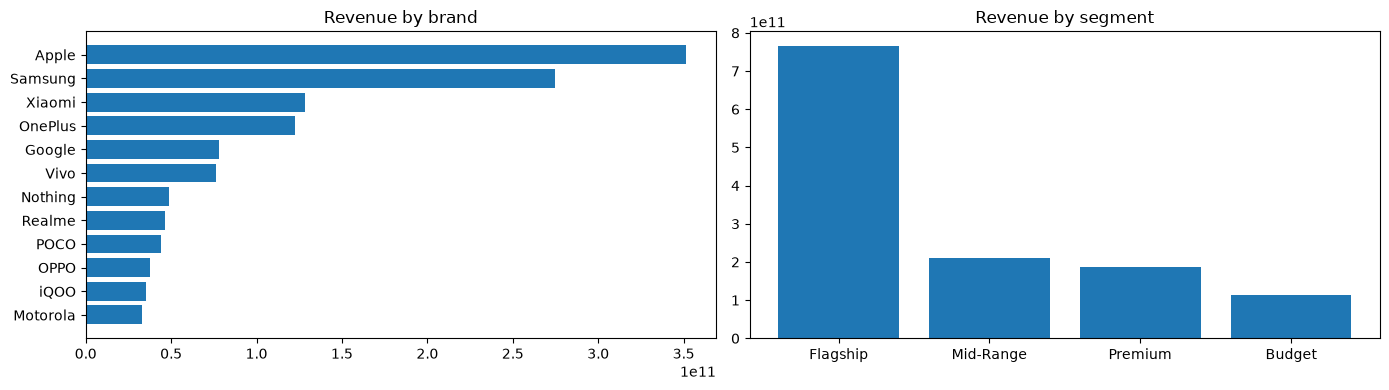

In [4]:
brand = analysis.brand_rollup(df)
seg = analysis.segment_rollup(df)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(brand["brand"], brand["revenue"]); axes[0].invert_yaxis(); axes[0].set_title("Revenue by brand")
axes[1].bar(seg["segment"], seg["revenue"]); axes[1].set_title("Revenue by segment")
plt.tight_layout(); plt.show()

## Price vs rating correlation

Pearson price vs rating: 0.725


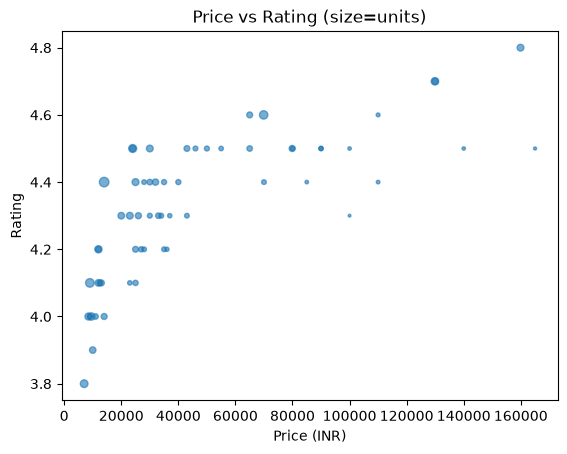

In [5]:
print("Pearson price vs rating:", df["price_inr"].corr(df["rating"]).round(3))
plt.scatter(df["price_inr"], df["rating"], s=df["units_sold"]/30000, alpha=0.6)
plt.xlabel("Price (INR)"); plt.ylabel("Rating"); plt.title("Price vs Rating (size=units)"); plt.show()

## Quarterly trend by segment

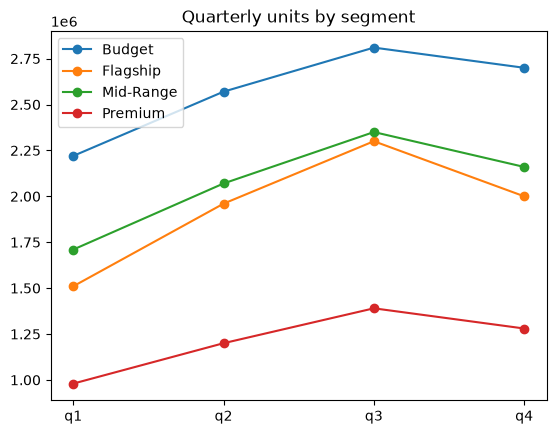

In [6]:
q = analysis.quarterly_trend(df)
for seg_name, g in q.groupby("segment"):
    plt.plot(g["quarter"], g["units"], marker="o", label=seg_name)
plt.legend(); plt.title("Quarterly units by segment"); plt.show()

## Key insights
- Flagship drives a disproportionate share of revenue despite fewer units.
- Budget/Mid-Range dominate unit volume.
- Higher price shows a strong positive correlation with rating (Pearson ≈ 0.725).
_(Confirm against the figures above.)_